# Baseline Forecasting Models
This notebook builds naive, historical average, window average, and seasonal naive baseline forecasts for `air_so2` using the cleaned dataset.
We train on all but the last 12 observations and test on the final 12.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [2]:
# Load cleaned data
data_path = '../COS40007DataCleaning/combined_air_electricity_ipi_cleaned.csv'
df = pd.read_csv(data_path)
df.head()

,date,air_co,air_no2,air_o3,air_pm_10,air_pm_25,air_so2,electricity_exports,electricity_local,electricity_local_commercial,electricity_local_domestic,electricity_losses,electricity_total,ipi_abs_index,ipi_growth_mom_index,ipi_growth_yoy_index,ipi_abs_index_sa,ipi_growth_mom_index_sa,ipi_growth_yoy_index_sa
0,2018-01-01,0.671,0.0078,0.015,19.14,11.43,0.0010,109.820,11845.900250,9390.080801,2455.819450,1200.383806,13156.104056,113.447,1.264,4.838,109.866,0.013,3.963
1,2018-02-01,0.677,0.0069,0.024,26.06,16.75,0.0011,101.500,11091.957006,8561.415143,2530.541863,903.839625,12097.296631,101.820,-10.249,2.344,110.830,0.877,2.625
2,2018-03-01,0.654,0.0074,0.019,24.84,15.61,0.0010,103.785,12244.089947,9659.320215,2584.769732,1681.104546,14028.979493,112.270,10.264,2.921,111.090,0.235,3.328
3,2018-04-01,0.682,0.0075,0.019,25.64,16.34,0.0010,102.002,12018.584577,9340.784017,2677.800560,1484.235112,13604.821689,108.986,-2.925,4.977,113.036,1.752,5.918
4,2018-05-01,0.671,0.0076,0.017,22.60,14.54,0.0010,142.261,12267.998390,9525.937602,2742.060788,1524.423335,13934.682725,111.631,2.426,3.502,112.183,-0.755,4.320


In [3]:
# Use air_so2 as the target series
target_column = 'air_so2'
series = df[target_column].astype(float).reset_index(drop=True)
horizon = 12
window = 12
season_length = 12

train = series.iloc[:-horizon].reset_index(drop=True)
test = series.iloc[-horizon:].reset_index(drop=True)

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test.values.reshape(-1, 1)).flatten()

print(f'Test points:  {len(test)}')

print(f'Total points: {len(series)}')
print(f'Train points: {len(train)}')

Test points:  12
Total points: 60
Train points: 48


In [4]:
def naive_forecast(train_series, horizon):
    return np.full(horizon, train_series.iloc[-1])

def historic_average_forecast(train_series, horizon):
    return np.full(horizon, train_series.mean())

def window_average_forecast(train_series, horizon, window):
    return np.full(horizon, train_series.iloc[-window:].mean())

def seasonal_naive_forecast(train_series, horizon, season_length):
    seasonal_values = train_series.iloc[-season_length:].values
    repeated = np.tile(seasonal_values, int(np.ceil(horizon / season_length)))
    return repeated[:horizon]

def evaluate_forecast(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred),
    }


In [5]:
forecasts = {
    'naive': naive_forecast(pd.Series(train_scaled), horizon),
    'historic_average': historic_average_forecast(pd.Series(train_scaled), horizon),
    'window_average': window_average_forecast(pd.Series(train_scaled), horizon, window),
    'seasonal_naive': seasonal_naive_forecast(pd.Series(train_scaled), horizon, season_length),
}

# Inverse transform forecasts back to original air_so2 scale before evaluation
forecast_orig = {
    name: scaler.inverse_transform(forecast.reshape(-1, 1)).flatten()
    for name, forecast in forecasts.items()
}

results = {}
for name, forecast in forecast_orig.items():
    metrics = evaluate_forecast(test.values, forecast)
    results[name] = metrics

results_df = pd.DataFrame(results).T[['mae', 'rmse', 'r2']]
results_df

,mae,rmse,r2
naive,0.000025,0.000050,-0.028571
historic_average,0.000135,0.000144,-7.544643
window_average,0.000081,0.000090,-2.314286
seasonal_naive,0.000092,0.000096,-2.771429


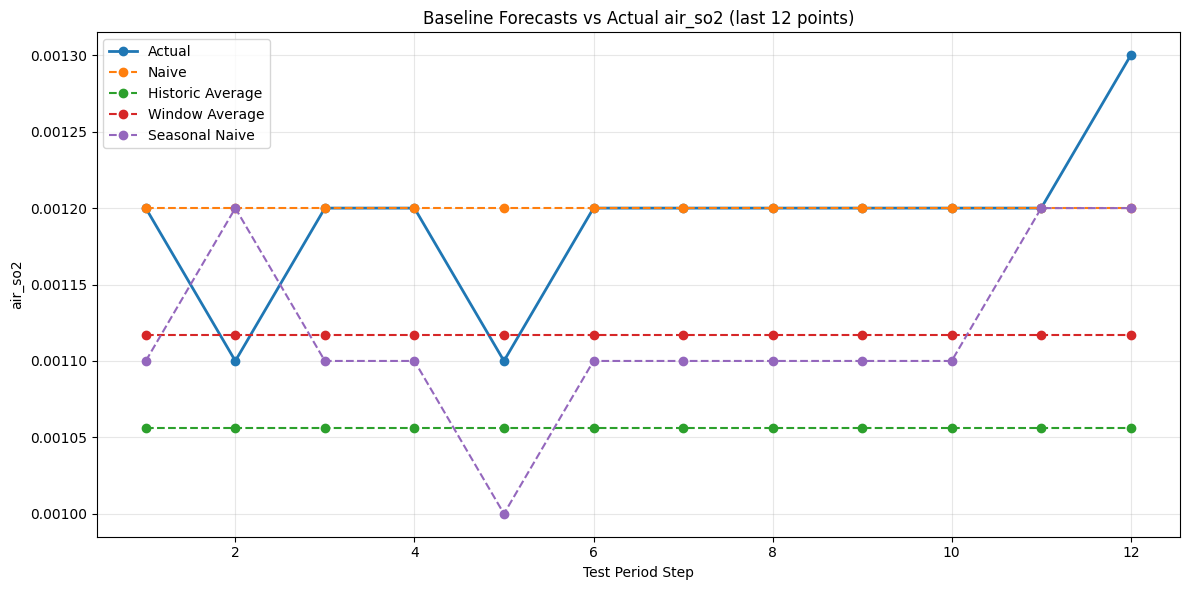

In [6]:
# Plot the actual test data and each baseline forecast
plt.figure(figsize=(12, 6))
x = np.arange(1, horizon + 1)
plt.plot(x, test.values, marker='o', label='Actual', linewidth=2)
for name, forecast in forecast_orig.items():
    plt.plot(x, forecast, marker='o', linestyle='--', label=name.replace('_', ' ').title())

plt.title('Baseline Forecasts vs Actual air_so2 (last 12 points)')
plt.xlabel('Test Period Step')
plt.ylabel('air_so2')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()